# Solar Eclipse & Eye Health

**Autora:** Beatriz Herrera León

**Fecha:** Agosto 2026

## Objetivo

En este proyecto se analiza la relación entre los eclipses solares y la salud ocular, utilizando datos procedentes de publicaciones científicas.

A partir de diferentes estudios sobre retinopatía solar, lesiones oculares, visitas a urgencias y medidas de protección, se pretende explorar la incidencia de estas lesiones y su posible relación con la observación de eclipses solares.

El análisis se ha realizado mediante Python, utilizando Pandas para la organización y exploración de los datos, y Matplotlib y Plotly para su visualización. Además, se ha utilizado Dash para la creación de un dashboard interactivo que permite presentar los principales resultados del análisis.

#### 1. Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

#### 2. Obtención de publicaciones científicas

Para contextualizar el análisis, se utilizarán publicaciones científicas relacionadas con la retinopatía solar y los eclipses solares.
Los artículos se obtendrán mediante la API de PubMed, utilizando una búsqueda relacionada con `solar retinopathy` y `eclipse`.
Posteriormente, se analizarán los resultados obtenidos para identificar información relevante sobre lesiones oculares asociadas a los eclipses solares.

In [2]:
# Búsqueda de publicaciones en PubMed

busqueda = "solar retinopathy eclipse"
url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
params = { "db": "pubmed", "term": busqueda, "retmax": 100, "retmode": "json"}

response = requests.get(url, params=params)
data = response.json()

pubmed_ids = data["esearchresult"]["idlist"]

print(f"Artículos encontrados: {len(pubmed_ids)}")

Artículos encontrados: 59


#### 3. Obtención de información de los artículos

In [3]:
# Obtener información de los artículos

fetch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

fetch_params = {"db": "pubmed", "id": ",".join(pubmed_ids), "retmode": "json"}

response = requests.get(fetch_url, params=fetch_params)
articles_data = response.json()

In [4]:
# Extraemos la información relevante de los artículos

articles = []

for pmid in pubmed_ids:
    article = articles_data["result"][pmid]

    articles.append({"PMID": pmid, "Title": article.get("title"), "Journal": article.get("fulljournalname"), "Year": article.get("pubdate", "")[:4]})

df_articles = pd.DataFrame(articles)

df_articles.head()

,PMID,Title,Journal,Year
0,42608570,[Solar retinopathy: clinical diagnosis and cou...,Die Ophthalmologie,2026
1,42164909,Eye on the Eclipse: Demographic Trends in Sola...,Journal of vitreoretinal diseases,2026
2,41573477,A Case of Bilateral Macular Phototoxicity and ...,Cureus,2025
3,41554171,Incidence of Solar Retinopathy and Photokerati...,The western journal of emergency medicine,2026
4,41059240,Swept-Source Optical Coherence Tomography and ...,Beyoglu eye journal,2025


#### 4. Selección de artículos relevantes

De los 58 resultados obtenidos mediante la búsqueda en PubMed, se seleccionaron tres artículos por su relevancia para el análisis de la retinopatía solar, la incidencia de lesiones oculares y las medidas de prevención.

In [5]:
# Seleccionamos los tres artículos más relevantes para el análisis
ids_seleccionados = ['42164909', '41554171', '27643600']

##### 4.1. Evolución de los casos de retinopatía solar

Los siguientes datos proceden del artículo **"Eye on the Eclipse: Demographic Trends in Solar Retinopathy From 2012 to 2024"** (PMID: 42164909).

El estudio analiza la incidencia de retinopatía solar en Estados Unidos entre 2012 y 2024. Para este proyecto se han seleccionado algunos de los datos descritos en el artículo con el objetivo de estudiar la relación entre la aparición de casos de retinopatía solar y los años en los que se produjeron eclipses solares.

En concreto, se comparan la media anual de casos, el número de casos registrado en 2017 y la media de casos correspondiente a los años con eclipse y a los años sin eclipse.

In [6]:
# Datos de casos de retinopatía solar 
datos_retinopatia = pd.DataFrame({ 'periodo': ['Media anual','2017', 'Años con eclipse','Años sin eclipse' ],'casos': [44.5, 71, 51.5, 37.3]})
datos_retinopatia

,periodo,casos
0,Media anual,44.5
1,2017,71.0
2,Años con eclipse,51.5
3,Años sin eclipse,37.3


##### Visualización de los casos de retinopatía solar

Para facilitar la comparación entre los diferentes periodos analizados, se representa mediante un gráfico de barras el número de casos de retinopatía solar.

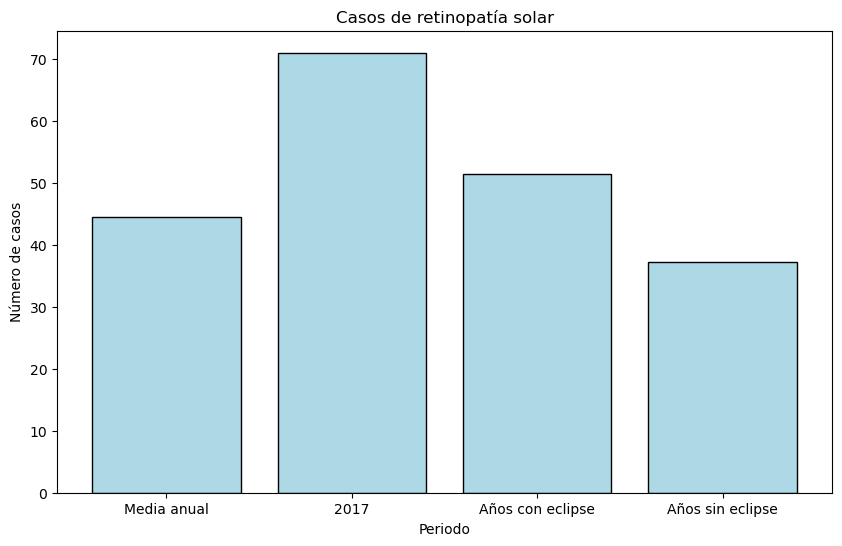

In [7]:
plt.figure(figsize=(10,6))
plt.bar(datos_retinopatia['periodo'], datos_retinopatia['casos'], color='lightblue', edgecolor='black')

plt.title('Casos de retinopatía solar')
plt.xlabel('Periodo')
plt.ylabel('Número de casos')

plt.show()

##### Interpretación del gráfico

El gráfico muestra que el número de casos de retinopatía solar fue superior a la media anual en 2017, con 71 casos frente a una media de 44,5 casos anuales.

Además, se observa una mayor incidencia media en los años en los que se produjeron eclipses (51,5 casos) en comparación con los años sin eclipse (37,3 casos). Estos datos sugieren una posible relación entre los eclipses solares y un aumento de los casos de retinopatía solar.

#### 4.2. Visitas a urgencias por lesiones oculares antes y después del eclipse

Los siguientes datos proceden de un estudio que analizó las visitas a los servicios de urgencias por lesiones oculares antes y después del eclipse solar del 8 de abril de 2024.

Para este análisis se han seleccionado los datos correspondientes al número de visitas registradas antes y después del eclipse, con el objetivo de observar si se produjo una variación en las consultas por lesiones oculares tras el evento.

In [8]:
# Datos de visitas a urgencias 
datos_urgencias = pd.DataFrame({'periodo': ['Antes del eclipse', 'Después del eclipse'],'visitas': [853, 921]})
datos_urgencias

,periodo,visitas
0,Antes del eclipse,853
1,Después del eclipse,921


##### Visualización de las visitas a urgencias

Para comparar visualmente el número de visitas registradas antes y después del eclipse, se representa la información mediante un gráfico de barras.

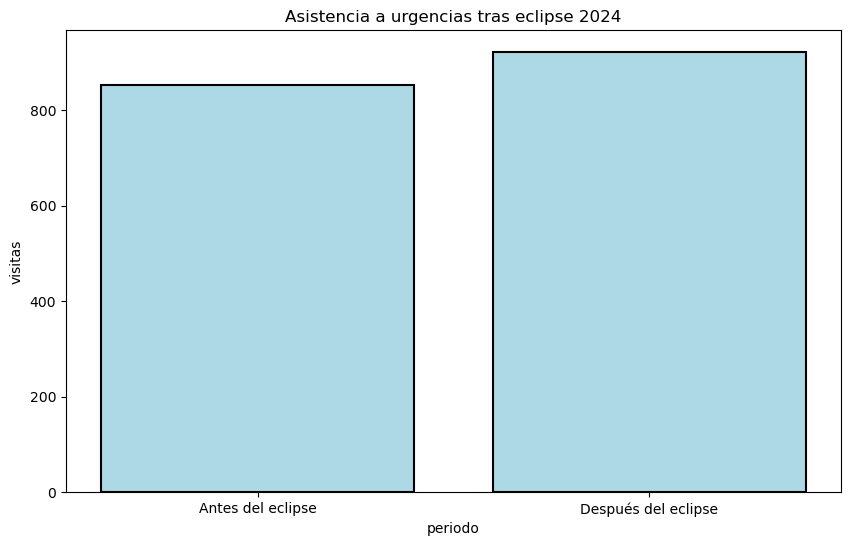

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(datos_urgencias['periodo'], datos_urgencias['visitas'], color='lightblue', edgecolor='black', linewidth=1.5)

plt.title('Asistencia a urgencias tras eclipse 2024')
plt.xlabel('periodo')
plt.ylabel('visitas')

plt.show()

##### Interpretación del gráfico

Se observa un aumento en el número de visitas a urgencias por lesiones oculares después del eclipse. El número de visitas pasó de 853 antes del eclipse a 921 después, lo que supone un incremento de 68 visitas.

Este aumento podría indicar una mayor incidencia de lesiones oculares después del eclipse, aunque estos datos por sí solos no permiten establecer que el eclipse sea la causa directa de dicho incremento.

##### 4.3. Información sobre prevención y protección ocular en medios de comunicación

Los siguientes datos proceden de un estudio que analizó la información sobre los riesgos de observar un eclipse solar y los métodos de protección ocular publicada en 31 periódicos online de seis países europeos antes del eclipse de 2015.

Para este análisis se han seleccionado tres indicadores: el número total de periódicos analizados, los periódicos que mencionaron el riesgo ocular y aquellos que recomendaron el uso de gafas específicas para la observación de eclipses.

In [10]:
# Datos sobre prevención ocular 
prevencion_ocular = pd.DataFrame({'indicador': ['Periódicos analizados', 'Mencionaron riesgo ocular','Mencionaron gafas para eclipses' ],
    'cantidad': [31, 31, 29]})
prevencion_ocular

,indicador,cantidad
0,Periódicos analizados,31
1,Mencionaron riesgo ocular,31
2,Mencionaron gafas para eclipses,29


##### Visualización de la información sobre prevención ocular

Para comparar los diferentes indicadores, se representa mediante un gráfico de barras el número de periódicos que incluyeron información sobre los riesgos o las medidas de protección ocular.

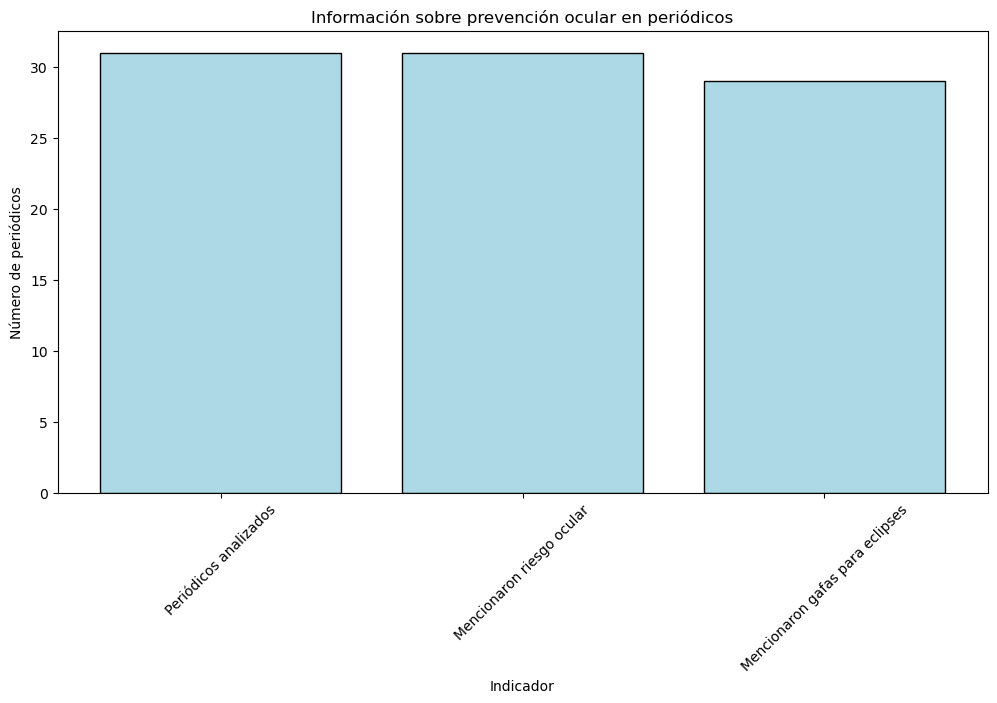

In [11]:
plt.figure(figsize=(12,6))
plt.bar(prevencion_ocular['indicador'], prevencion_ocular['cantidad'], color='lightblue', edgecolor='black')
plt.xticks(rotation=45)

plt.title('Información sobre prevención ocular en periódicos')
plt.xlabel('Indicador')
plt.ylabel('Número de periódicos')

plt.show()

##### Interpretación del gráfico

El gráfico muestra que los 31 periódicos analizados mencionaron el riesgo ocular asociado a la observación de un eclipse solar. Sin embargo, el uso de gafas específicas para eclipses fue mencionado en 29 de los 31 periódicos.

Por tanto, aunque la información sobre el riesgo ocular estaba presente en todos los medios analizados, no todos incluyeron una recomendación concreta sobre el uso de gafas para eclipses.

#### 5. Análisis conjunto

A partir de los datos obtenidos de los tres estudios seleccionados, se realiza un análisis conjunto para identificar posibles patrones relacionados con los eclipses solares y la salud ocular.

Los resultados se comparan teniendo en cuenta las diferencias entre las fuentes y las características de los datos analizados.

In [12]:
# Análisis conjunto
resumen_estudios = pd.DataFrame({'estudio': ['Retinopatía solar','Visitas a urgencias','Prevención ocular' ],
    'indicador': ['Casos medios en años con eclipse', 'Visitas después del eclipse','Periódicos que mencionaron gafas'],
    'valor': [ 51.5, 921, 29]})

resumen_estudios

,estudio,indicador,valor
0,Retinopatía solar,Casos medios en años con eclipse,51.5
1,Visitas a urgencias,Visitas después del eclipse,921.0
2,Prevención ocular,Periódicos que mencionaron gafas,29.0


##### 5.1 Comparación de casos de retinopatía en años con y sin eclipse

Para analizar los resultados del estudio sobre retinopatía solar, se comparan los casos medios registrados en años con eclipse y en años sin eclipse.

Se calcula la diferencia entre ambos valores para observar si existe una mayor incidencia media de casos en los años en los que se producen eclipses.

In [13]:
casos_eclipse = datos_retinopatia[datos_retinopatia['periodo'] == 'Años con eclipse']['casos'].values[0] 
casos_eclipse

np.float64(51.5)

In [14]:
casos_sin_eclipse= datos_retinopatia[datos_retinopatia['periodo'] == 'Años sin eclipse']['casos'].values[0]
casos_sin_eclipse

np.float64(37.3)

In [15]:
diferencia_casos = casos_eclipse - casos_sin_eclipse
diferencia_casos

np.float64(14.200000000000003)

In [16]:
diferencia_casos = round(casos_eclipse - casos_sin_eclipse, 1)
diferencia_casos

np.float64(14.2)

In [17]:
urgencias_antes = datos_urgencias.loc[datos_urgencias['periodo'] == 'Antes del eclipse', 'visitas'].iloc[0]
urgencias_antes

np.int64(853)

In [18]:
urgencias_despues = datos_urgencias.loc[datos_urgencias['periodo'] == 'Después del eclipse', 'visitas'].iloc[0]
urgencias_despues

np.int64(921)

In [19]:
diferencia_urgencias = urgencias_despues - urgencias_antes
diferencia_urgencias 

np.int64(68)

In [20]:
periodicos_analizados = prevencion_ocular.loc[prevencion_ocular['indicador'] == 'Periódicos analizados', 'cantidad'].iloc[0]
periodicos_analizados

np.int64(31)

In [21]:
periodicos_gafas = prevencion_ocular.loc[prevencion_ocular['indicador'] == 'Mencionaron gafas para eclipses','cantidad'].iloc[0]
periodicos_gafas

np.int64(29)

In [22]:
porcentaje_gafas = round((periodicos_gafas / periodicos_analizados) * 100, 1)
porcentaje_gafas

np.float64(93.5)

##### 5.2 Resumen de indicadores

A partir de los datos obtenidos de los tres estudios, se calculan algunos indicadores que permiten resumir los principales resultados del análisis conjunto.

Estos indicadores se utilizarán posteriormente para facilitar la comparación y la visualización de los resultados.

In [23]:
indicadores = pd.DataFrame({'indicador': ['Diferencia de casos de retinopatía', 'Diferencia de visitas a urgencias',
        'Periódicos que mencionaron gafas' ],'valor': [diferencia_casos, diferencia_urgencias, porcentaje_gafas]})
indicadores

,indicador,valor
0,Diferencia de casos de retinopatía,14.2
1,Diferencia de visitas a urgencias,68.0
2,Periódicos que mencionaron gafas,93.5


#### 6. Visualización interactiva

Para complementar las visualizaciones estáticas anteriores, se utilizará Plotly para crear gráficos interactivos que permitan explorar los resultados del análisis de forma más dinámica.

In [24]:
import plotly.graph_objects as go

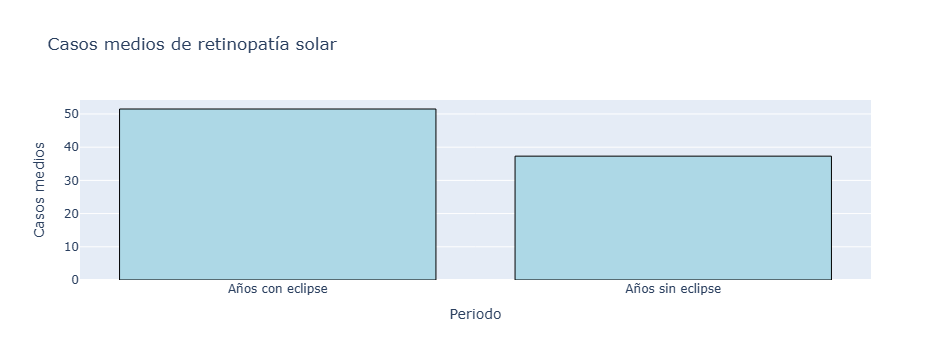

In [25]:
fig = go.Figure() 

fig.add_trace(go.Bar(
    x=['Años con eclipse', 'Años sin eclipse'],
    y=[casos_eclipse, casos_sin_eclipse], marker_color = 'lightblue', marker_line_color = 'black', marker_line_width=1))

fig.update_layout(
    title='Casos medios de retinopatía solar',
    xaxis_title='Periodo',
    yaxis_title='Casos medios')

fig.show()


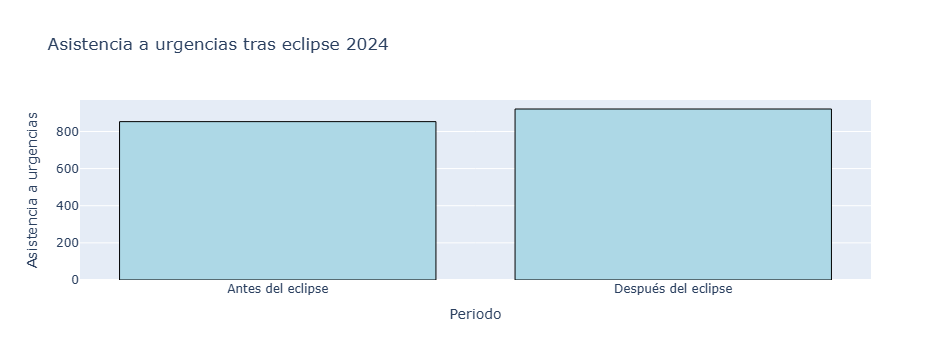

In [31]:
fig2 = go.Figure() 

fig2.add_trace (go.Bar(x=['Antes del eclipse', 'Después del eclipse'], y=[urgencias_antes, urgencias_despues],
                       marker_line_color='black', marker_line_width=1, marker_color='lightblue'))
fig2.update_layout(title='Asistencia a urgencias tras eclipse 2024', xaxis_title='Periodo', yaxis_title='Asistencia a urgencias')
fig2.show()

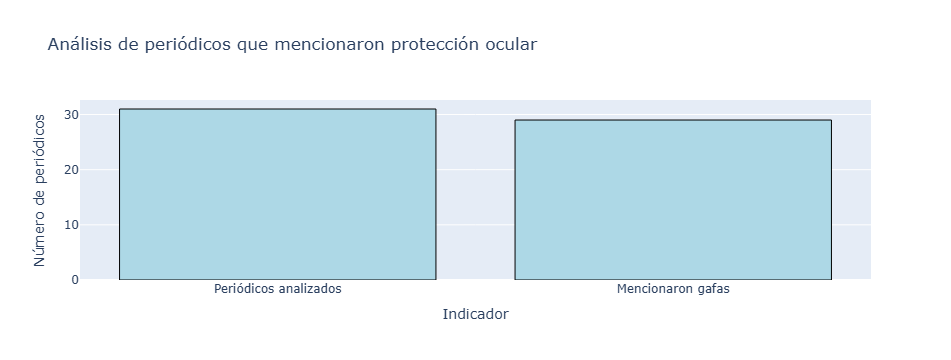

In [27]:
fig3 = go.Figure()

fig3.add_trace(go.Bar(x=['Periódicos analizados', 'Mencionaron gafas'], y=[periodicos_analizados, periodicos_gafas],
                      marker_line_width=1, marker_line_color='black', marker_color='lightblue'))
fig3.update_layout(title='Análisis de periódicos que mencionaron protección ocular', xaxis_title='Indicador',
                   yaxis_title='Número de periódicos')
fig3.show()


##### 6.1 Dashboard interactivo

Para facilitar la exploración de los resultados obtenidos, se desarrolla un dashboard interactivo utilizando Plotly.

El dashboard reúne las principales visualizaciones del análisis y permite interactuar con los gráficos para consultar los datos de una forma más dinámica.

In [28]:
# Importación de librerias 
import dash
from dash import dcc, html

In [29]:
app = dash.Dash(__name__)

##### Estructura del dashboard

In [33]:
app.layout = html.Div([
    html.H1('Eclipses solares y salud ocular'),

    html.Div([
        dcc.Graph(figure=fig),
        dcc.Graph(figure=fig2)
    ], style={'display': 'flex'}),

    dcc.Graph(figure=fig3)
])

In [34]:
app.run(debug=True, port=8051)

### 7. Análisis conjunto y conclusiones

A partir de los resultados obtenidos en el análisis de los estudios seleccionados, se realiza una interpretación conjunta de los datos con el objetivo de identificar los principales patrones observados y extraer conclusiones sobre la relación entre los eclipses solares y la salud ocular.

#### 7.1 Variación de los casos de lesiones oculares
En el estudio de retinopatía solar analizado se observa una diferencia en el número medio de casos entre los años con eclipse y los años sin eclipse. Los años con eclipse registraron una media de 51,5 casos, frente a 37,3 casos en los años sin eclipse, lo que supone una diferencia de 14,2 casos.

Estos resultados muestran una mayor frecuencia de casos en los años en los que se produjeron eclipses. Sin embargo, los datos analizados no permiten establecer que el eclipse sea por sí mismo la causa de este aumento, por lo que el resultado debe interpretarse como una asociación observada en el estudio.

#### 7.2 Relación con la protección ocular

Uno de los aspectos analizados fue la presencia de recomendaciones sobre protección ocular durante los eclipses. Para ello, se calculó el porcentaje de periódicos analizados que mencionaron específicamente el uso de gafas de protección para eclipses.

El análisis muestra que el 93,5 % de los periódicos analizados incluyeron esta recomendación. Este resultado indica una elevada presencia de información sobre protección ocular en los medios analizados.

Sin embargo, estos datos no permiten determinar si los lectores utilizaron correctamente las gafas ni establecer una relación causal entre la información publicada y la aparición de lesiones oculares.

#### 7.3 Periodo con mayor número de casos
El valor más elevado de los datos analizados corresponde a 2017, con una media de 71 casos, superando tanto la media anual general (44,5) como la media de los años con eclipse (51,5). 
Este resultado identifica 2017 como el período con mayor número de casos dentro del conjunto de datos analizado, pero no permite atribuir este incremento directamente a la presencia de un eclipse.

### 7.4 Conclusión final

El análisis realizado muestra una mayor frecuencia de casos de retinopatía solar en los años con eclipse respecto a los años sin eclipse, con una diferencia de 14,2 casos en la media analizada. Además, se observa una elevada presencia de recomendaciones sobre protección ocular en los medios estudiados, ya que el 93,5 % de los periódicos analizados mencionaron el uso de gafas de protección.

Estos resultados permiten observar una posible relación entre los eclipses solares, la aparición de lesiones oculares y la importancia de la prevención. No obstante, el conjunto de datos analizado es limitado y procede de estudios con características diferentes, por lo que los resultados no permiten establecer relaciones causales ni generalizar las conclusiones a toda la población. El proyecto muestra, principalmente, cómo el análisis y la visualización de datos pueden utilizarse para explorar cuestiones relacionadas con la salud ocular.